# MCMC methods, and when inference falls apart

**Day 2, 15:00 — 30 minutes.** Alexander Fengler.

Everything you fitted this morning and at 14:30 converged quietly. That is
not guaranteed, and the failures teach more than the successes. This session
has two halves:

1. **what MCMC is actually doing** — including writing a sampler from scratch
   in ten lines, so it stops being a black box;
2. **what makes a posterior hard**, on the cognitive model you just fitted.

One idea runs through both. A posterior can be hard because of its **shape**,
and past a certain point no amount of sampler tuning repairs a bad shape —
you have to change the sampler, or change the experiment.

In [1]:
import sys, pathlib, warnings, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-mcmc"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. What is MCMC actually trying to do?

We have a distribution $\pi(\theta)$ over some parameter space, and we want
to compute expectations under it:

$$
\mathbb{E}_{\pi}[f] \;=\; \int f(\theta)\, \pi(\theta) \, d\theta .
$$

A posterior mean is $f(\theta) = \theta$; a credible interval is a couple of
quantiles; a posterior predictive is an expectation of the likelihood. All of
them are integrals against $\pi$.

In more than two or three dimensions those integrals are hopeless
analytically and hopeless on a grid. So we give up on computing them and
instead **draw samples** $\theta^{(1)}, \dots, \theta^{(N)} \sim \pi$ and
average:

$$
\mathbb{E}_{\pi}[f] \;\approx\; \frac{1}{N} \sum_{i=1}^{N} f\!\left(\theta^{(i)}\right).
$$

<details class="sbi-note">
<summary>📝 <b><i>&pi;</i> does not have to be a posterior</b></summary>

Nothing above mentions Bayes. MCMC is a general recipe for sampling from *any*
distribution you can evaluate up to a constant — it is used in statistical
physics, combinatorial optimisation and rendering. We happen to point it at
posteriors, and for the first examples below $\pi$ will just be a distribution
we picked because we know the right answer.

</details>

### The normalizing constant, and why we can ignore it

For a posterior, Bayes' rule says

$$
\pi(\theta) \;=\; p(\theta \mid y) \;=\;
\frac{p(y \mid \theta)\, p(\theta)}{p(y)},
\qquad p(y) = \int p(y \mid \theta) p(\theta)\, d\theta .
$$

The numerator is easy: it is the likelihood times the prior, both of which you
wrote down. The denominator $p(y)$ — the **evidence** — is an integral over
the whole parameter space, and it is exactly the kind of integral we just
admitted we cannot do.

The escape is that **every MCMC algorithm only ever looks at ratios**. Write
the unnormalised density as $\tilde{\pi}(\theta) = p(y \mid \theta)p(\theta)$,
so $\pi = \tilde{\pi} / p(y)$. Then for any two points,

$$
\frac{\pi(\theta')}{\pi(\theta)}
\;=\; \frac{\tilde{\pi}(\theta') / p(y)}{\tilde{\pi}(\theta) / p(y)}
\;=\; \frac{\tilde{\pi}(\theta')}{\tilde{\pi}(\theta)} .
$$

**$p(y)$ cancels.** That single cancellation is what makes Bayesian
computation possible at all: you never need the evidence to *sample* the
posterior — only to compare whole models against each other.

## 2. A Metropolis sampler in ten lines

The oldest MCMC algorithm, and still the clearest. From the current point
$\theta$:

1. **propose** a nearby point, $\theta' = \theta + \varepsilon$ with
   $\varepsilon \sim \text{Normal}(0, s^2)$;
2. **accept** it with probability
   $\alpha = \min\!\left(1,\ \tilde{\pi}(\theta')/\tilde{\pi}(\theta)\right)$;
3. if accepted move there, otherwise **stay put and record the current point
   again**.

Because the proposal is symmetric, that ratio is the whole rule. Step 3 is the
part people find strange: rejecting does not mean discarding the iteration, it
means the chain repeats itself — which is how low-density regions end up
visited proportionally *less*, rather than never.

In [2]:
def metropolis(log_target, start, n_steps=20_000, step_size=1.0, seed=0):
    """Random-walk Metropolis. `log_target` need only be correct up to a constant."""
    rng = np.random.default_rng(seed)
    theta = np.atleast_1d(np.asarray(start, dtype=float))
    logp = log_target(theta)
    chain, n_accept = np.empty((n_steps, theta.size)), 0

    for i in range(n_steps):
        proposal = theta + rng.normal(0.0, step_size, theta.size)
        logp_prop = log_target(proposal)
        # accept with probability min(1, pi(prop)/pi(theta)) — in logs
        if np.log(rng.uniform()) < logp_prop - logp:
            theta, logp = proposal, logp_prop
            n_accept += 1
        chain[i] = theta

    return chain, n_accept / n_steps

To show that the normalizing constant genuinely does not matter, target a
distribution written **without** one. This is a Gaussian mixture whose true
density we happen to know, so we can check the answer:

acceptance rate 0.50


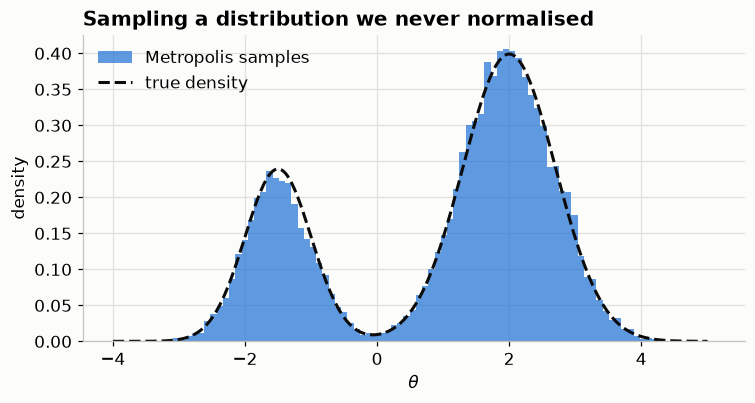

In [3]:
def log_target_mixture(theta):
    """log of an UNNORMALISED two-component mixture. No 1/sqrt(2*pi) anywhere."""
    x = theta[0]
    return np.log(np.exp(-0.5 * ((x - 2.0) / 0.7) ** 2)
                  + 0.6 * np.exp(-0.5 * ((x + 1.5) / 0.5) ** 2))


chain, acc = metropolis(log_target_mixture, start=[0.0], step_size=1.5,
                        n_steps=40_000, seed=RANDOM_SEED)
print(f"acceptance rate {acc:.2f}")

grid = np.linspace(-4, 5, 400)
dens = np.exp([log_target_mixture([g]) for g in grid])
dens /= np.trapezoid(dens, grid)          # normalise only for PLOTTING

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(chain[2000:, 0], bins=90, density=True, color=S.PRIMARY, alpha=0.75,
        label="Metropolis samples")
ax.plot(grid, dens, color=S.TRUTH, ls="--", lw=2, label="true density")
ax.set(title="Sampling a distribution we never normalised",
       xlabel=r"$\theta$", ylabel="density")
ax.legend()
fig.tight_layout()

Twelve lines of Python, no gradients, no library — and the histogram lands on
the density. Note that we **never computed the normalizing constant**; the
sampler only ever saw ratios.

> **Poll.** Our proposal was symmetric: $\theta' = \theta + \text{Normal}(0, s^2)$.
> What breaks if the proposal is *asymmetric* and we keep this same rule?
>
> - **A.** Nothing — the chain still targets $\pi$.
> - **B.** The chain converges to the wrong distribution.
> - **C.** The chain still works but mixes more slowly.
> - **D.** The acceptance rate goes to zero.

<details>
<summary>Answer</summary>

**B.** With an asymmetric proposal you must include the proposal ratio too —
the Metropolis–**Hastings** correction,
$\alpha = \min(1,\ [\tilde{\pi}(\theta')q(\theta \mid \theta')] /
[\tilde{\pi}(\theta)q(\theta' \mid \theta)])$. Omit it and the chain converges
happily to something that is not your target, with no warning. Our symmetric
Gaussian proposal makes $q$ cancel, which is why we could leave it out.

</details>

### The knob that decides everything

`step_size` is the whole art of a random-walk sampler. Too small and every
proposal is accepted but the chain barely moves; too large and almost
everything is rejected so the chain barely moves. Both failures look like
"high" or "reasonable" acceptance rates.

In [4]:
rows = []
for s in [0.05, 0.5, 1.5, 5.0, 20.0]:
    ch, a = metropolis(log_target_mixture, start=[0.0], step_size=s,
                       n_steps=20_000, seed=RANDOM_SEED)
    x = ch[2000:, 0]
    ess = float(az.ess(az.convert_to_datatree({"x": x[None, :]}),
                       var_names=["x"]).x)
    rows.append({"step_size": s, "acceptance": a, "ESS": ess,
                 "ESS/draw": ess / x.size})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

 step_size  acceptance       ESS  ESS/draw
     0.050       0.970    56.313     0.003
     0.500       0.757    71.015     0.004
     1.500       0.505  1125.020     0.063
     5.000       0.258  2437.447     0.135
    20.000       0.072   818.132     0.045


<details class="sbi-key" open>
<summary>🔑 <b>Acceptance rate is not a measure of quality</b></summary>

The smallest step size has by far the **highest** acceptance rate and among
the **worst** ESS — it accepts everything because it proposes almost nothing.
Judge a sampler by effective sample size, never by how often it says yes.

</details>

Notice what that table let us do: we **tuned our way out of trouble**. There
was a bad setting and a good one, we found the good one, and the sampler
worked. Hold on to that, because the next target takes it away.

## 3. When there is no good step size

The mixture was hard in an *easy* way: one knob, and a right answer for it.
Now a target that is much simpler to write down and much harder to sample — a
two-dimensional Gaussian with correlation $\rho$:

$$
\log \tilde{\pi}(x_0, x_1) \;=\;
-\,\frac{x_0^2 - 2\rho\, x_0 x_1 + x_1^2}{2\,(1 - \rho^2)} .
$$

No multimodality, no heavy tails, no awkward constraint. Just an ellipse. As
$\rho \to 1$ that ellipse becomes a long thin ridge along the diagonal, and
that alone is enough to defeat the sampler we just wrote.

In [5]:
def log_target_gaussian(rho):
    """Unnormalised 2-D Gaussian, unit marginals, correlation rho."""
    denom = 2.0 * (1.0 - rho**2)

    def log_target(theta):
        x0, x1 = theta[0], theta[1]
        return -(x0**2 - 2.0 * rho * x0 * x1 + x1**2) / denom

    return log_target


# The ellipse has a long axis along (1, 1) and a short axis along (1, -1).
# Everything below reads more clearly in those coordinates than in x0 / x1.
ALONG = np.array([1.0, 1.0]) / np.sqrt(2.0)      # up the ridge
ACROSS = np.array([1.0, -1.0]) / np.sqrt(2.0)    # across it

RHOS = [0.0, 0.9, 0.99]
for rho in RHOS:
    # the sd along each axis is sqrt(1 +/- rho)
    print(f"rho = {rho:4.2f}:  length {np.sqrt(1 + rho):.3f}   "
          f"width {np.sqrt(1 - rho):.3f}   "
          f"aspect ratio {np.sqrt((1 + rho) / (1 - rho)):6.2f} : 1")

rho = 0.00:  length 1.000   width 1.000   aspect ratio   1.00 : 1
rho = 0.90:  length 1.378   width 0.316   aspect ratio   4.36 : 1
rho = 0.99:  length 1.411   width 0.100   aspect ratio  14.11 : 1


At $\rho = 0.99$ the target is **fourteen times longer than it is wide**. A
random-walk proposal is a *circle* — the same size step in every direction —
and no circle fits a shape like that.

In [6]:
def run_chains(log_target, step_size, n_chains=4, n_steps=25_000, warmup=5_000):
    """Several independent chains, so an ESS estimate is not one seed's luck."""
    kept, accs = [], []
    for c in range(n_chains):
        ch, a = metropolis(log_target, start=[0.0, 0.0], n_steps=n_steps,
                           step_size=step_size, seed=RANDOM_SEED + c)
        kept.append(ch[warmup:])
        accs.append(a)
    return np.stack(kept), float(np.mean(accs))     # (chain, draw, 2)


def ess_per_draw(chains, direction):
    """ESS as a fraction of draws, for the projection onto `direction`."""
    projected = chains @ direction                   # (chain, draw)
    dt = az.convert_to_datatree({"x": projected})
    return float(az.ess(dt, var_names=["x"]).x) / projected.size


STEPS = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
sweep = []
for rho in RHOS:
    lt = log_target_gaussian(rho)
    for s in STEPS:
        chains, acc = run_chains(lt, s)
        sweep.append({"rho": rho, "step_size": s, "acceptance": acc,
                      "ESS/draw along": ess_per_draw(chains, ALONG),
                      "ESS/draw across": ess_per_draw(chains, ACROSS)})
sweep = pd.DataFrame(sweep)

for rho in RHOS:
    print(f"\n--- rho = {rho} " + "-" * 46)
    print(sweep[sweep.rho == rho].drop(columns="rho")
          .to_string(index=False, float_format=lambda v: f"{v:10.4f}"))


--- rho = 0.0 ----------------------------------------------
 step_size  acceptance  ESS/draw along  ESS/draw across
    0.0500      0.9751          0.0004           0.0003
    0.1000      0.9500          0.0022           0.0019
    0.2500      0.8771          0.0133           0.0143
    0.5000      0.7592          0.0401           0.0410
    1.0000      0.5539          0.0972           0.1051
    2.0000      0.2928          0.1247           0.1314
    4.0000      0.1067          0.0662           0.0620

--- rho = 0.9 ----------------------------------------------
 step_size  acceptance  ESS/draw along  ESS/draw across
    0.0500      0.9476          0.0002           0.0061
    0.1000      0.8950          0.0008           0.0210
    0.2500      0.7466          0.0065           0.0944
    0.5000      0.5462          0.0174           0.1884
    1.0000      0.3133          0.0337           0.1827
    2.0000      0.1381          0.0413           0.0904
    4.0000      0.0480          0.02

### The squeeze

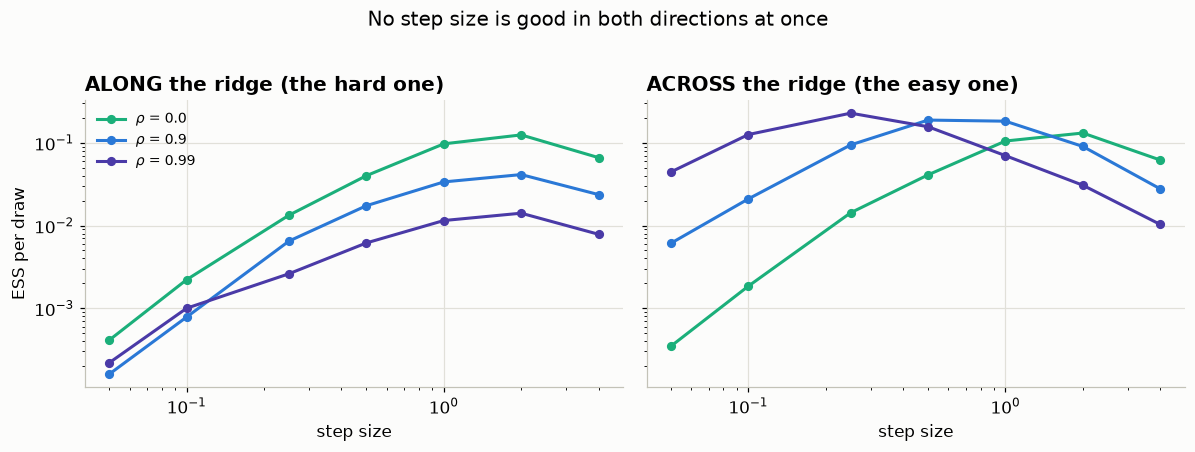

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, direction, name in [(axes[0], "along", "ALONG the ridge (the hard one)"),
                            (axes[1], "across", "ACROSS the ridge (the easy one)")]:
    for rho, colour in zip(RHOS, [S.ALT, S.PRIMARY, S.NAIVE]):
        block = sweep[sweep.rho == rho]
        ax.plot(block["step_size"], block[f"ESS/draw {direction}"], "o-",
                color=colour, label=f"$\\rho$ = {rho}")
    ax.set(xscale="log", yscale="log", xlabel="step size", title=name)
axes[0].set_ylabel("ESS per draw")
axes[0].legend(fontsize=9)
fig.suptitle("No step size is good in both directions at once", y=1.02)
fig.tight_layout()

In [8]:
worst = sweep[sweep.rho == 0.99]
best_along = worst.loc[worst["ESS/draw along"].idxmax()]
best_across = worst.loc[worst["ESS/draw across"].idxmax()]
uncorrelated = sweep[sweep.rho == 0.0]["ESS/draw along"].max()

print("at rho = 0.99:")
print(f"  best step size ALONG  the ridge: {best_along['step_size']:5.2f}"
      f"   (ESS/draw {best_along['ESS/draw along']:.4f})")
print(f"  best step size ACROSS the ridge: {best_across['step_size']:5.2f}"
      f"   (ESS/draw {best_across['ESS/draw across']:.4f})")
print("  -> the two directions want DIFFERENT step sizes, and you get one.\n")
print(f"  best achievable along the ridge : {best_along['ESS/draw along']:.4f}")
print(f"  best achievable when rho = 0    : {uncorrelated:.4f}")
print(f"  -> even at its own optimum, "
      f"{uncorrelated / best_along['ESS/draw along']:.0f}x worse than "
      "the uncorrelated target.")

at rho = 0.99:
  best step size ALONG  the ridge:  2.00   (ESS/draw 0.0141)
  best step size ACROSS the ridge:  0.25   (ESS/draw 0.2285)
  -> the two directions want DIFFERENT step sizes, and you get one.

  best achievable along the ridge : 0.0141
  best achievable when rho = 0    : 0.1247
  -> even at its own optimum, 9x worse than the uncorrelated target.


That is the difference from the mixture. There, tuning *worked* — there was a
good step size and it was genuinely good. Here every step size is bad, in one
of two ways:

- **small steps** stay inside the narrow width, so they are almost always
  accepted, and they crawl along a ridge fourteen times longer than it is wide;
- **large steps** are big enough to travel the ridge, but a *circular* step
  that large mostly lands off the ridge sideways, and is rejected.

The two failures meet in a flat, mediocre middle. There is no knife-edge
setting you might have missed — the whole range is poor, and the best of it is
an order of magnitude below what the same sampler achieves on a round target.

<details class="sbi-warn" open>
<summary>⚠️ <b>A correct-looking answer from a chain that did not work</b></summary>

The most dangerous cell in that table is the small-step one, because of what
it reports about itself. Run it and look:

</details>

In [9]:
chains_bad, acc_bad = run_chains(log_target_gaussian(0.99), step_size=0.05)
n_draws = chains_bad[..., 0].size
ess_bad = ess_per_draw(chains_bad, ALONG)

print(f"step_size 0.05, rho 0.99:  acceptance {acc_bad:.1%}")
print(f"  sd(x0) from the chain = {chains_bad[..., 0].std():.3f}"
      "   (the truth is exactly 1.000)")
print(f"  ESS/draw along the ridge = {ess_bad:.5f}")
print(f"  -> about {ess_bad * n_draws:.0f} independent draws out of {n_draws:,}")

step_size 0.05, rho 0.99:  acceptance 84.4%
  sd(x0) from the chain = 0.967   (the truth is exactly 1.000)
  ESS/draw along the ridge = 0.00022
  -> about 18 independent draws out of 80,000


A marginal standard deviation in the right neighbourhood is **not** evidence
that the chain worked. This one lands within a few percent of the truth while
containing a couple of dozen genuinely independent samples — and it does so
because the marginal it got roughly right is the direction it was *not*
struggling in. Check ESS and $\hat{R}$; do not eyeball whether the numbers
look plausible.

## 4. The same target, in PyMC

Two things are worth showing here. First, **PyMC gives you Metropolis too** —
the sampler we hand-wrote is a library call, and swapping it in is one
argument. Second, and the reason this section exists: **NUTS crosses this
target without being tuned at all.**

In [10]:
def gaussian_pymc_model(rho):
    """A PyMC model whose posterior IS the correlated Gaussian — no data needed."""
    cov = np.array([[1.0, rho], [rho, 1.0]])
    with pm.Model() as model:
        pm.MvNormal("x", mu=np.zeros(2), cov=cov, shape=2)
    return model


# `step=` picks the sampler. `pm.Metropolis()` must be constructed INSIDE the
# model context — outside it you get "TypeError: No model on context stack".
with gaussian_pymc_model(0.99):
    idata_mh = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                         step=pm.Metropolis(), progressbar=False,
                         random_seed=RANDOM_SEED)

print("Metropolis:")
print(az.summary(idata_mh, kind="diagnostics").to_string())

Sequential sampling (2 chains in 1 job)


Metropolis: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Metropolis:
      ess_bulk  ess_tail r_hat mcse_mean mcse_sd
x[0]         8         7  1.24      0.34    0.28
x[1]         8         7  1.24      0.34    0.28


`ess_bulk` in the single digits, and $\hat{R}$ far past the 1.01 threshold —
out of 4000 draws. PyMC prints warnings saying exactly this. Same model, same
budget, NUTS:

In [11]:
with gaussian_pymc_model(0.99):
    idata_nuts = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                           nuts_sampler="pymc", progressbar=False,
                           random_seed=RANDOM_SEED)

print("NUTS:")
print(az.summary(idata_nuts, kind="diagnostics").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


NUTS:
      ess_bulk  ess_tail r_hat mcse_mean mcse_sd
x[0]       703       868  1.00     0.037   0.026
x[1]       684       892  1.00     0.037   0.026


### How far does this go?

Push the correlation further and measure both samplers properly — including
whether the answer is *right*, not merely how fast it arrives.

In [12]:
def assess(idata, rho, sampler, seconds):
    x = idata.posterior.dataset["x"].values              # (chain, draw, 2)
    stats = idata["sample_stats"].dataset
    return {
        "rho": rho, "sampler": sampler,
        "ESS/draw along": ess_per_draw(x, ALONG),
        # the honest check: is the posterior the right WIDTH?
        "sd along": float((x @ ALONG).std()),
        "sd true": float(np.sqrt(1 + rho)),
        "seconds": seconds,
        # NUTS reports gradient evaluations per draw; Metropolis has no analogue
        "grad/draw": float(stats["n_steps"].mean()) if "n_steps" in stats else np.nan,
    }


rows = []
for rho in [0.9, 0.99, 0.999]:
    for sampler in ["Metropolis", "NUTS"]:
        t0 = time.time()
        with gaussian_pymc_model(rho):
            if sampler == "Metropolis":
                idata = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                                  step=pm.Metropolis(), progressbar=False,
                                  random_seed=RANDOM_SEED)
            else:
                idata = pm.sample(draws=2000, tune=2000, chains=2, cores=1,
                                  nuts_sampler="pymc", progressbar=False,
                                  random_seed=RANDOM_SEED)
        rows.append(assess(idata, rho, sampler, time.time() - t0))

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

Sequential sampling (2 chains in 1 job)


Metropolis: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

Sequential sampling (2 chains in 1 job)


NUTS: [x]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


      rho    sampler  ESS/draw along  sd along   sd true   seconds  grad/draw
    0.900 Metropolis           0.018     1.437     1.378     0.192        NaN
    0.900       NUTS           0.256     1.437     1.378     0.771      5.536
    0.990 Metropolis           0.002     1.300     1.411     0.220        NaN
    0.990       NUTS           0.173     1.375     1.411     1.130     12.354
    0.999 Metropolis           0.001     1.551     1.414     0.206        NaN
    0.999       NUTS           0.158     1.423     1.414     2.603     33.404


Read the `sd along` column against `sd true` beside it before anything else.

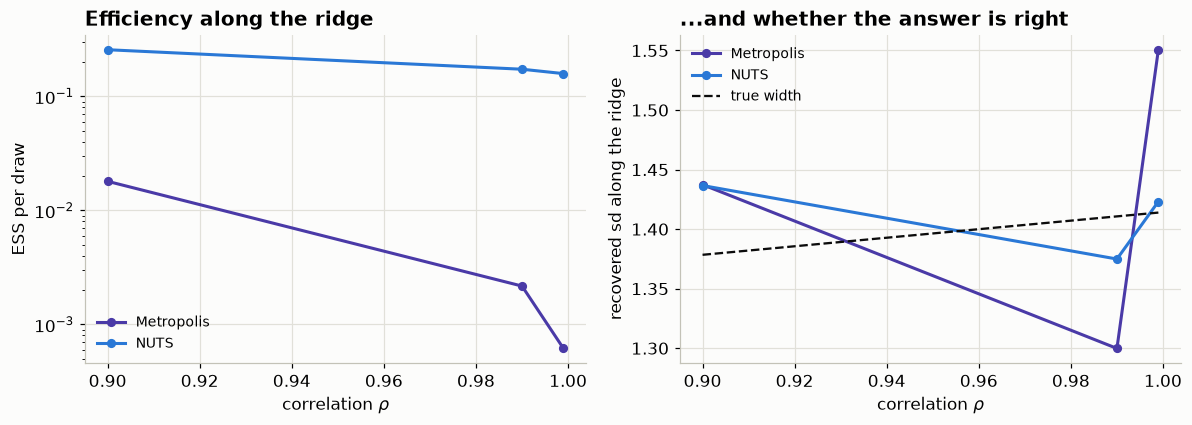

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rho_grid = comparison["rho"].unique()

ax = axes[0]
for sampler, colour in [("Metropolis", S.NAIVE), ("NUTS", S.PRIMARY)]:
    b = comparison[comparison.sampler == sampler]
    ax.plot(b["rho"], b["ESS/draw along"], "o-", color=colour, label=sampler)
ax.set(yscale="log", xlabel=r"correlation $\rho$", ylabel="ESS per draw",
       title="Efficiency along the ridge")
ax.legend(fontsize=9)

ax = axes[1]
for sampler, colour in [("Metropolis", S.NAIVE), ("NUTS", S.PRIMARY)]:
    b = comparison[comparison.sampler == sampler]
    ax.plot(b["rho"], b["sd along"], "o-", color=colour, label=sampler)
ax.plot(rho_grid, np.sqrt(1 + rho_grid), "--", color=S.TRUTH, lw=1.5,
        label="true width")
ax.set(xlabel=r"correlation $\rho$", ylabel="recovered sd along the ridge",
       title="...and whether the answer is right")
ax.legend(fontsize=9)
fig.tight_layout()

<details class="sbi-key" open>
<summary>🔑 <b>Slow is survivable; unreliable is not</b></summary>

At high correlation Metropolis does not merely mix slowly — the width it
reports stops being **reliable**. Compare its `sd along` to `sd true` at each
row: it misses in one direction at one correlation and the other direction at
the next, by margins of several percent to over ten, with no pattern. NUTS
tracks the truth throughout.

That unpredictability is the danger, and it is worse than a consistent bias
would be. A chain that has not travelled a direction is reporting a summary of
the part of that direction it happened to visit — which could be too narrow
(it never reached the ends) or too wide (it wandered off and got stuck). You
cannot tell which from the chain, and nothing raises an error. That is why
$\hat{R}$ and ESS are not optional.

NUTS instead keeps its ESS per draw roughly flat. What it pays is **compute**:
the `grad/draw` column climbs as the geometry worsens, because it needs longer
trajectories to cross the ridge. Ill-conditioning turns into a larger bill
rather than into a wrong number — that is the trade you want.

</details>

## 5. *Advanced:* Gibbs has the same problem, for a different reason

*(Skip if we are short on time — nothing later depends on it.)*

You might reasonably suspect the trouble was our clumsy tuning. So take tuning
off the table completely.

For this Gaussian the **conditional** distributions are known in closed form:

$$
x_0 \mid x_1 \;\sim\; \text{Normal}\!\left(\rho\, x_1,\ \sqrt{1-\rho^2}\right),
$$

and symmetrically. A **Gibbs sampler** simply alternates: draw $x_0$ given
$x_1$, then $x_1$ given the new $x_0$. There is no step size, no proposal and
**no rejection** — every draw is exact and every draw is accepted.

In [14]:
def gibbs(rho, n_steps=25_000, seed=RANDOM_SEED, record_path=False):
    """Coordinate-wise Gibbs. Nothing to tune; acceptance is 1 by construction."""
    rng_g = np.random.default_rng(seed)
    sd = np.sqrt(1.0 - rho**2)
    x = np.zeros(2)
    chain = np.empty((n_steps, 2))
    path = [x.copy()]

    for i in range(n_steps):
        x[0] = rng_g.normal(rho * x[1], sd)      # x0 | x1
        if record_path:
            path.append(x.copy())
        x[1] = rng_g.normal(rho * x[0], sd)      # x1 | x0
        if record_path:
            path.append(x.copy())
        chain[i] = x

    return (chain, np.array(path)) if record_path else chain


gibbs_chains = {rho: np.stack([gibbs(rho, seed=RANDOM_SEED + c)[5_000:]
                               for c in range(4)])
                for rho in RHOS}

rows = []
for rho in RHOS:
    ch = gibbs_chains[rho]
    # Lag-1 autocorrelation via the ArviZ accessor. The `draw` axis of the
    # RESULT is the lag, so index 1 is lag one.
    dt = az.convert_to_datatree({"x": ch[..., 0]})
    lag1 = float(dt.azstats.autocorr(dim="draw")["x"].isel(chain=0, draw=1))
    rows.append({"rho": rho, "lag-1 of x0": lag1, "rho^2 (theory)": rho**2,
                 "ESS/draw along": ess_per_draw(ch, ALONG),
                 "ESS/draw across": ess_per_draw(ch, ACROSS)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:10.4f}"))

       rho  lag-1 of x0  rho^2 (theory)  ESS/draw along  ESS/draw across
    0.0000       0.0021          0.0000          1.0036           0.9902
    0.9000       0.8164          0.8100          0.0978           1.1058
    0.9900       0.9823          0.9801          0.0110           1.0161


Two things in that table.

**The theory is exact.** For this target Gibbs turns each coordinate into an
AR(1) process with lag-1 correlation exactly $\rho^2$, and the measurement
lands on it. So a sampler with no knobs and a 100% acceptance rate is
nonetheless *guaranteed* to be slow here, by an amount you can write down
before running it.

**The failure is directional.** Gibbs samples *across* the ridge essentially
perfectly — ESS per draw near 1, as good as independent draws — while being
about a hundred times subsampled *along* it. It is not a bad sampler. It is a
sampler that is excellent in one direction and hopeless in the other.

The picture shows why:

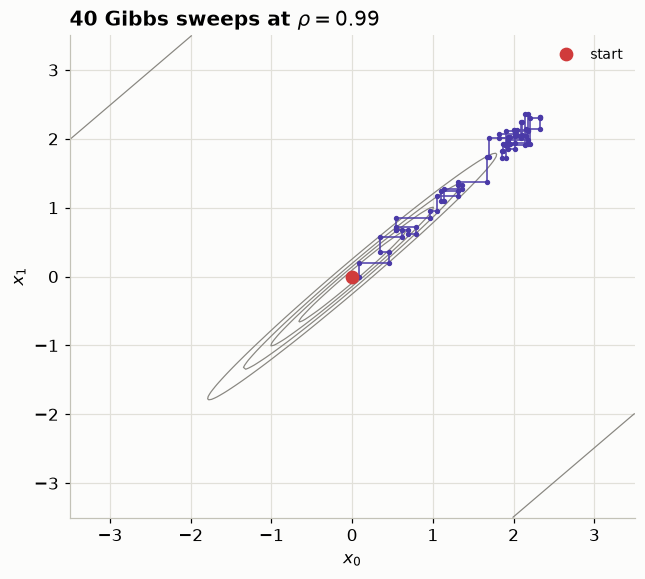

In [15]:
_, path = gibbs(0.99, n_steps=40, seed=RANDOM_SEED, record_path=True)

fig, ax = plt.subplots(figsize=(6.0, 5.4))
g = np.linspace(-3.5, 3.5, 200)
X0, X1 = np.meshgrid(g, g)
Z = np.exp(-(X0**2 - 2 * 0.99 * X0 * X1 + X1**2) / (2 * (1 - 0.99**2)))
ax.contour(X0, X1, Z, levels=5, colors=S.MUTED, linewidths=0.8)
ax.plot(path[:, 0], path[:, 1], "-", color=S.NAIVE, lw=1.1, alpha=0.9)
ax.plot(path[:, 0], path[:, 1], "o", color=S.NAIVE, ms=2.5, ls="none")
ax.plot(path[0, 0], path[0, 1], "o", color=S.DIVERGENT, ms=8, label="start")
ax.set(title=r"40 Gibbs sweeps at $\rho = 0.99$", xlabel="$x_0$", ylabel="$x_1$",
       xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
ax.legend(fontsize=9)
fig.tight_layout()

Every move is **horizontal or vertical**, because every move updates one
coordinate. The ridge runs at 45°. So the chain can only climb it as a
staircase of tiny right-angled steps, each limited by the *width* of the ridge
rather than by its length. Nothing here is tunable: the constraint is the
**coordinate system**, not the step length.

In [16]:
step_along = np.diff(gibbs_chains[0.99][0] @ ALONG)
print("at rho = 0.99, per Gibbs sweep:")
print(f"  rms movement ALONG the ridge : {step_along.std():.3f}")
print(f"  the ridge's own length (sd)  : {np.sqrt(1 + 0.99):.3f}")
print(f"  -> one sweep covers {step_along.std() / np.sqrt(1.99):.1%} of the ridge")

at rho = 0.99, per Gibbs sweep:
  rms movement ALONG the ridge : 0.241
  the ridge's own length (sd)  : 1.411
  -> one sweep covers 17.1% of the ridge


<details class="sbi-note">
<summary>📝 <b>Is Gibbs worse than Metropolis here? No — and that is the point</b></summary>

Compare the two tables honestly. Along the ridge Gibbs lands in much the same
place as a *well-tuned* random-walk Metropolis, and across the ridge it is
comfortably better — and it got there with no step-size sweep at all. That is
a genuine practical advantage.

But it is still two orders of magnitude short of independent sampling, and
**no setting exists that would fix it**, because there is no setting. Two
quite different algorithms, defeated by the same ellipse. That is what tells
you the problem was never the algorithm.

One connection worth noticing: `pm.Metropolis()` in the previous section also
updates a vector one coordinate at a time. Its moves are axis-aligned too, so
it inherits precisely this weakness.

</details>

## 6. When the problem is the *posterior*, not the sampler

Everything so far used a target we invented, with a correlation we chose. Now
the cognitive model — where the same geometry shows up without anyone asking
for it, and where you cannot fix it by changing sampler.

At 14:30 everything recovered cleanly. Here are two datasets from the **same**
DDM, differing only in drift rate — and therefore in how often the participant
makes an error.

In [17]:
from hssm.likelihoods import DDM
from ssms import Simulator

DRAWS, TUNE, CHAINS = 700, 700, 2
# z = 0.65 puts the start point above the midpoint, so the process begins nearer
# the "+1" boundary. That asymmetry is what makes the geometry legible later.
# v_balanced is set to land the error rate inside the 15-35% band that the
# design literature recommends — with a biased start point that takes a smaller
# drift than you might expect.
TRUE = {"v_balanced": 0.2, "v_extreme": 3.0, "a": 1.2, "z": 0.65, "t": 0.3}
PARAMS = ["v", "a", "z", "t"]


def make(v_true, n=600):
    o = Simulator(model="ddm").simulate(theta=[v_true, TRUE["a"], TRUE["z"], TRUE["t"]],
                                        n_samples=n, random_state=RANDOM_SEED)
    return np.column_stack([o["rts"].flatten(), o["choices"].flatten()])


def fit_ddm(observed, seed=RANDOM_SEED):
    with pm.Model():
        v = pm.Normal("v", 0.0, 3.0)
        a = pm.HalfNormal("a", 2.0)
        z = pm.Beta("z", 5.0, 5.0)
        t = pm.HalfNormal("t", 0.5)
        DDM("obs", v=v, a=a, z=z, t=t, observed=observed)
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False, random_seed=seed)


fits, posteriors, error_rates = {}, {}, {}
for label, v_true in [("balanced", TRUE["v_balanced"]), ("extreme", TRUE["v_extreme"])]:
    obs = make(v_true)
    error_rates[label] = (obs[:, 1] == -1).mean()
    idata = fit_ddm(obs)
    fits[label] = idata
    p = idata.posterior.dataset
    posteriors[label] = {k: p[k].values.ravel() for k in PARAMS}
    print(f"{label:9s} error rate {error_rates[label]:5.1%}   "
          + "  ".join(f"{k}={posteriors[label][k].mean():5.2f}" for k in PARAMS))
print(f"\ntruth: v={TRUE['v_balanced']} or {TRUE['v_extreme']}, a={TRUE['a']}, "
      f"z={TRUE['z']}, t={TRUE['t']}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 700 tune and 700 draw iterations (1_400 + 1_400 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 700 tune and 700 draw iterations (1_400 + 1_400 draws total) took 16 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


extreme   error rate  0.0%   v= 3.40  a= 1.44  z= 0.62  t= 0.28

truth: v=0.2 or 3.0, a=1.2, z=0.65, t=0.3


### The correlation structure is the diagnosis

Text(0.5, 1.02, 'Every parameter pair, both designs')

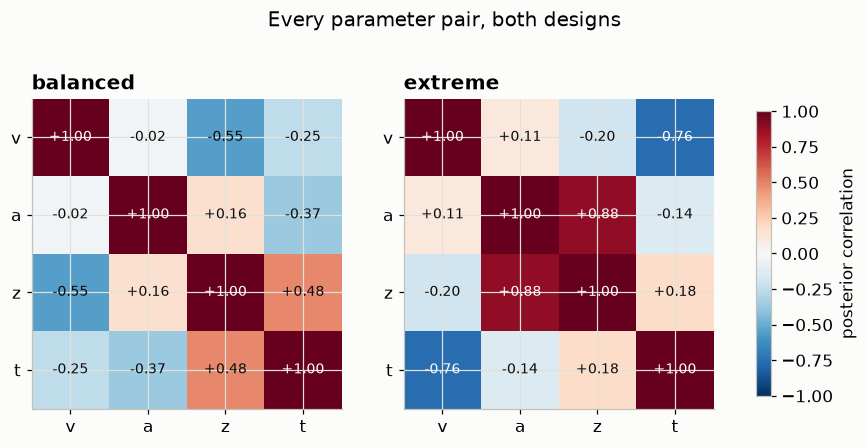

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, label in zip(axes, ["balanced", "extreme"]):
    d = posteriors[label]
    M = np.array([[np.corrcoef(d[i], d[j])[0, 1] for j in PARAMS] for i in PARAMS])
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set(xticks=range(4), yticks=range(4), title=label)
    ax.set_xticklabels(PARAMS); ax.set_yticklabels(PARAMS)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{M[i, j]:+.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(M[i, j]) > 0.55 else S.TRUTH)
fig.colorbar(im, ax=axes, shrink=0.8, label="posterior correlation")
fig.suptitle("Every parameter pair, both designs", y=1.02)

In the balanced design the correlations are moderate and *structured*. In the
extreme design one pair dominates everything else. Rank them and look:

In [19]:
def ranked_pairs(d):
    out = []
    for i, p in enumerate(PARAMS):
        for q in PARAMS[i + 1:]:
            out.append((f"{p}-{q}", np.corrcoef(d[p], d[q])[0, 1]))
    return sorted(out, key=lambda kv: -abs(kv[1]))


for label in ["balanced", "extreme"]:
    pairs = ranked_pairs(posteriors[label])
    print(f"{label:9s} " + "   ".join(f"{nm} {r:+.2f}" for nm, r in pairs))

balanced  v-z -0.55   z-t +0.48   a-t -0.37   v-t -0.25   a-z +0.16   v-a -0.02
extreme   a-z +0.88   v-t -0.76   v-z -0.20   z-t +0.18   a-t -0.14   v-a +0.11


The strongest pair in the extreme design is **`a` with `z`** — boundary
separation against start point — and the *weakest* is `v` with `a`. That is
worth pausing on, because `v`–`a` is the pair people reach for first.

### Why `a` and `z` collapse together

With essentially no errors, every single trial ended at the **same** boundary.
So ask what the data can possibly measure. The process starts at $z\,a$ and
has to travel

$$
\underbrace{a\,(1 - z)}_{\text{to the boundary it reaches}}
\qquad\text{versus}\qquad
\underbrace{a\,z}_{\text{to the boundary nobody ever reaches}} .
$$

Only the first of those leaves a trace in the data. And *that* distance is a
single number built from two parameters — so `a` and `z` are free to slide
together as long as their combination holds still.

In [20]:
def rel_width(x):
    """sd relative to the mean — comparable across parameters on different scales."""
    return x.std() / abs(x.mean())


print(f"{'quantity':30s} {'balanced':>10s} {'extreme':>10s}")
for name, f in [
    ("a  (boundary)", lambda d: d["a"]),
    ("z  (start point)", lambda d: d["z"]),
    ("a*(1-z)  distance travelled", lambda d: d["a"] * (1 - d["z"])),
    ("a*z      distance NOT travelled", lambda d: d["a"] * d["z"]),
]:
    print(f"{name:30s} {rel_width(f(posteriors['balanced'])):10.3f} "
          f"{rel_width(f(posteriors['extreme'])):10.3f}")

quantity                         balanced    extreme
a  (boundary)                       0.020      0.310
z  (start point)                    0.023      0.150
a*(1-z)  distance travelled         0.041      0.095
a*z      distance NOT travelled      0.033      0.476


There is the whole story in four rows. Read the `extreme` column top to
bottom: `a` on its own is badly determined, `z` on its own is poor, but the
distance the process actually **travelled** is the best-determined of the
three — and the distance to the boundary nobody ever reached is the worst of
the lot by a clear margin.

The data measured what happened. It could not measure what never happened.

This is also why `v`–`a` looks so weak: `a` on its own is not the
quantity the experiment sees. Combine it with `z` first, and the trade-off
reappears.

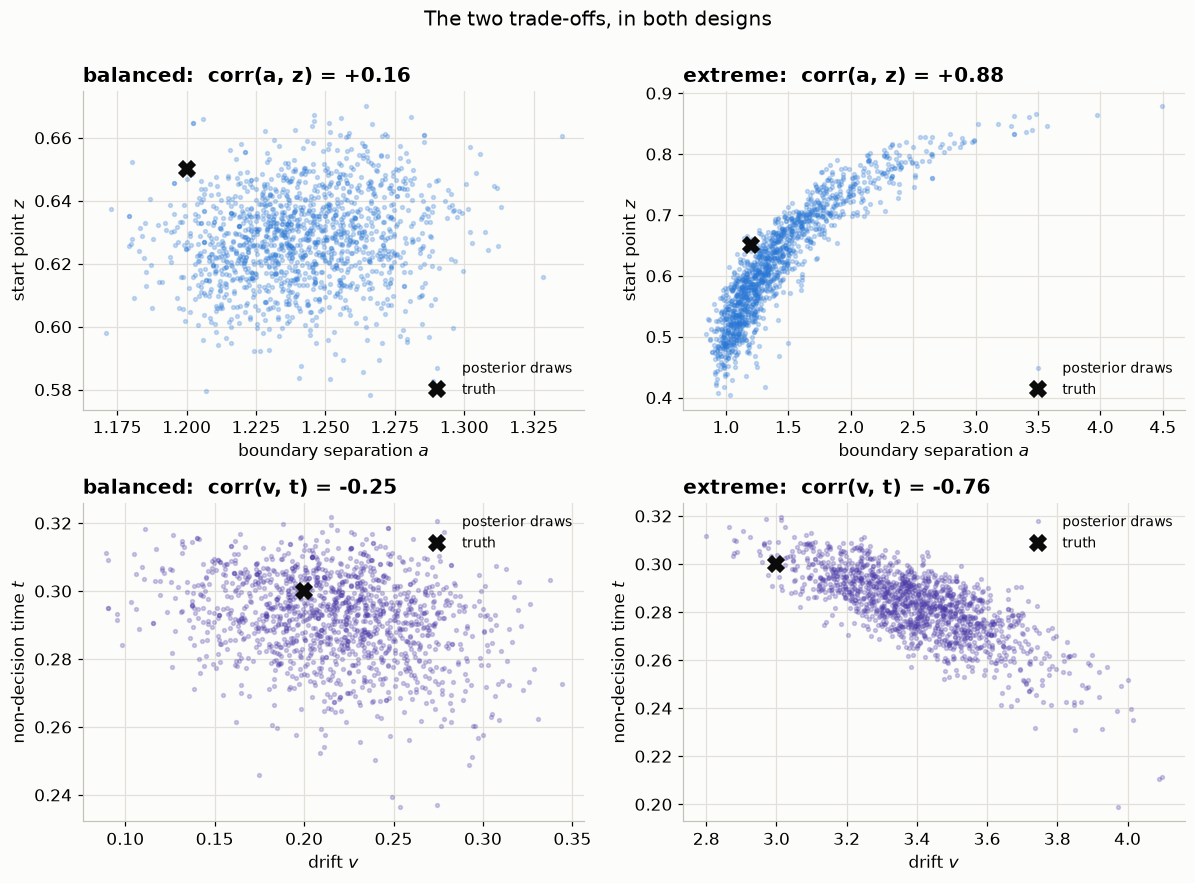

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col, label in enumerate(["balanced", "extreme"]):
    d = posteriors[label]

    ax = axes[0, col]
    r = np.corrcoef(d["a"], d["z"])[0, 1]
    ax.plot(d["a"], d["z"], "o", color=S.PRIMARY, ms=2.5, alpha=0.25, ls="none",
            label="posterior draws")
    S.truth_point(ax, TRUE["a"], TRUE["z"])
    ax.set(title=f"{label}:  corr(a, z) = {r:+.2f}",
           xlabel="boundary separation $a$", ylabel="start point $z$")
    ax.legend(loc="lower right", fontsize=9)

    ax = axes[1, col]
    r = np.corrcoef(d["v"], d["t"])[0, 1]
    ax.plot(d["v"], d["t"], "o", color=S.NAIVE, ms=2.5, alpha=0.25, ls="none",
            label="posterior draws")
    S.truth_point(ax, TRUE[f"v_{label}"], TRUE["t"])
    ax.set(title=f"{label}:  corr(v, t) = {r:+.2f}",
           xlabel="drift $v$", ylabel="non-decision time $t$")
    ax.legend(loc="upper right", fontsize=9)
fig.suptitle("The two trade-offs, in both designs", y=1.00)
fig.tight_layout()

Left column: compact blobs sitting on the truth. Right column: long thin
ridges. The truth is on each ridge — but so is every other point along it,
and the data have no way to say which.

The second row is the same failure in the time domain rather than the
geometry: total response time is non-decision time plus decision time, and
the fit can shuffle duration between the two while keeping the total fixed.

### What that costs you

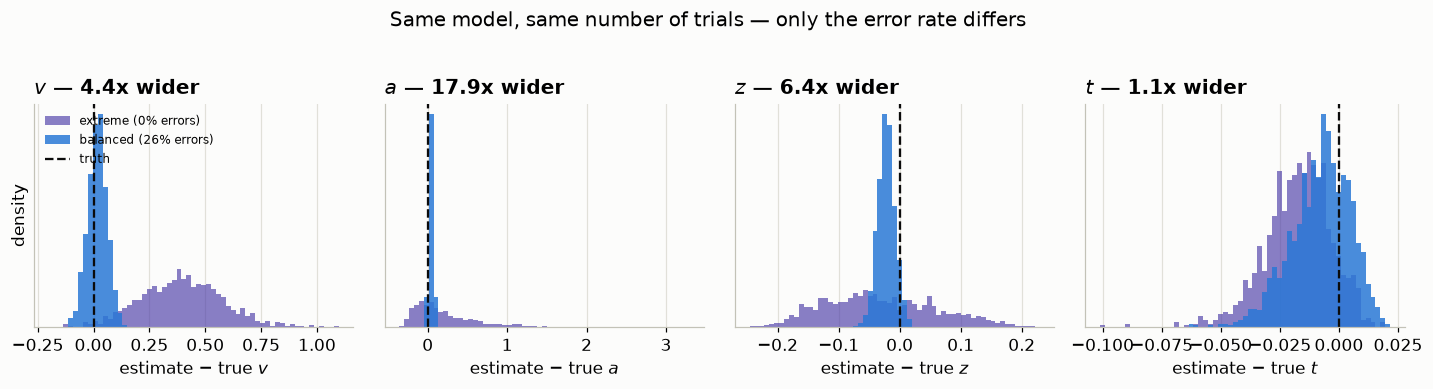

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, k in zip(axes, PARAMS):
    # Centre each design on ITS OWN truth, so the axis is estimation error and
    # the two designs are comparable even though true v differs between them.
    truth = {"v": None, "a": TRUE["a"], "z": TRUE["z"], "t": TRUE["t"]}[k]
    err = {lab: posteriors[lab][k] - (TRUE[f"v_{lab}"] if truth is None else truth)
           for lab in ["balanced", "extreme"]}

    lo = min(e.min() for e in err.values())
    hi = max(e.max() for e in err.values())
    bins = np.linspace(lo, hi, 60)

    ax.hist(err["extreme"], bins=bins, density=True, color=S.NAIVE, alpha=0.65,
            label=f"extreme ({error_rates['extreme']:.0%} errors)")
    ax.hist(err["balanced"], bins=bins, density=True, color=S.PRIMARY, alpha=0.85,
            label=f"balanced ({error_rates['balanced']:.0%} errors)")
    S.truth_line(ax, 0.0, axis="x")

    ratio = err["extreme"].std() / err["balanced"].std()
    ax.set(title=f"${k}$ — {ratio:.1f}x wider", xlabel=f"estimate $-$ true ${k}$",
           yticks=[])
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Same model, same number of trials — only the error rate differs",
             y=1.03)
fig.tight_layout()

In [23]:
for k in PARAMS:
    b, e = posteriors["balanced"][k].std(), posteriors["extreme"][k].std()
    print(f"sd({k}): {b:.4f} -> {e:.4f}   ({e / b:5.1f}x wider)")

sd(v): 0.0430 -> 0.1898   (  4.4x wider)
sd(a): 0.0248 -> 0.4444   ( 17.9x wider)
sd(z): 0.0145 -> 0.0928   (  6.4x wider)
sd(t): 0.0127 -> 0.0142   (  1.1x wider)


<details class="sbi-key" open>
<summary>🔑 <b>High accuracy is bad data for parameter estimation</b></summary>

This is the counterintuitive headline. Compare the two histograms in each
panel: the near-perfect dataset gives posteriors several times wider on every
parameter, lying along a ridge rather than filling a blob. Nothing is wrong
with the sampler and nothing is wrong with the model — **the experiment did
not collect the information**.

Notice that `t` is barely affected while `a` blows up. The damage is not
spread evenly.

Whether the point estimates also come out *biased* varies from dataset to
dataset, which is itself worth noticing: on a ridge, where the posterior mean
lands depends on where the prior and the little remaining information happen
to pull it. Sometimes you get lucky. You cannot tell from one fit which case
you are in — that is the problem.

</details>

### Exercise

We set the true start point to `z = 0.65`, above the midpoint. Predict what
happens to `corr(a, z)` if you push it to `0.80`, then check.

<details>
<summary>Answer</summary>

Change `TRUE["z"]` and re-run the extreme-design fit. The `a`–`z` correlation
stays strong — it is around `+0.84` to `+0.90` anywhere in this range, because
the mechanism does not depend on *which* boundary wins, only on the fact that
one of them always does.

What does change is `a` itself: the distance travelled is $a(1-z)$, so a
larger `z` means a smaller `a` reproduces the same data, and the posterior for
`a` shifts down accordingly.

The instructive part is what happens if you go the *other* way and set
`z = 0.5` with a balanced drift. Both trade-offs weaken at once, because now
both boundaries get reached and the data can see both distances. Identifiability
is a property of the **design**, not of the model.

</details>

**Next, tomorrow at 11:00:** today's difficulties came from correlation that
is roughly the same everywhere in parameter space. Hierarchical models bring a
nastier relative — curvature that *changes as you move* — where the failure
stops being inefficiency and becomes bias.